## Phase 1: Parse Log với Drain3

### Setup & Load Data

In [1]:
import os
import pandas as pd
from drain3 import TemplateMiner
from drain3.template_miner_config import TemplateMinerConfig

# 1. Khởi tạo đường dẫn và thư mục
log_file = "./data/Hadoop_2k.log"
output_dir = "results"
os.makedirs(output_dir, exist_ok=True)

# 2. Đọc file log và đếm tổng số dòng
with open(log_file, 'r', encoding='utf-8') as f:
    log_lines = f.readlines()

total_lines = len(log_lines)
print(f"Tổng số dòng log đã load: {total_lines:,}")

Tổng số dòng log đã load: 2,000


### Parse log với Drain3

In [2]:
import re

# 1. Khởi tạo cấu hình mặc định (drain_sim_th = 0.5 để tối ưu cho Hadoop log)
config = TemplateMinerConfig()
config.drain_sim_th = 0.5
miner = TemplateMiner(config=config)

# Pattern trích xuất phần message sau cụm "[thread] class:" của Hadoop log
hadoop_pattern = re.compile(r"^\d{4}-\d{2}-\d{2} \d{2}:\d{2}:\d{2},\d+ \w+ \[.*?\] [\w\.\$]+: (.*)$")

# 2. Parse toàn bộ log line qua parse tree của Drain3
print("Đang xử lý parsing...")
for line in log_lines:
    line_clean = line.strip()
    match = hadoop_pattern.match(line_clean)
    message = match.group(1) if match else line_clean
    miner.add_log_message(message)

# 3. Liệt kê tổng quan
clusters = miner.drain.clusters
print(f"Hoàn thành! Đã trích xuất được {len(clusters)} unique templates.")

# In thử 5 templates đầu tiên để kiểm tra (ground truth check)
print("\n--- Top 5 Templates Demo ---")
for cluster in list(clusters)[:5]:
    print(f"ID: {cluster.cluster_id} | Count: {cluster.size} | Template: {cluster.get_template()}")


Đang xử lý parsing...
Hoàn thành! Đã trích xuất được 103 unique templates.

--- Top 5 Templates Demo ---
ID: 1 | Count: 1 | Template: Created MRAppMaster for application appattempt_1445144423722_0020_000001
ID: 2 | Count: 1 | Template: Executing with tokens:
ID: 3 | Count: 1 | Template: Kind: YARN_AM_RM_TOKEN, Service: , Ident: (appAttemptId { application_id { id: 20 cluster_timestamp: 1445144423722 } attemptId: 1 } keyId: -127633188)
ID: 4 | Count: 1 | Template: Using mapred newApiCommitter.
ID: 5 | Count: 1 | Template: OutputCommitter set in config null


### Export Top-10 Templates ra CSV

In [3]:
# 1. Lấy danh sách toàn bộ clusters và sort theo tần suất (count) giảm dần
sorted_clusters = sorted(clusters, key=lambda x: x.size, reverse=True)

# 2. Lấy top 10
top_10_templates = []
for cluster in sorted_clusters[:10]:
    top_10_templates.append({
        "template_id": cluster.cluster_id,
        "template": cluster.get_template(),
        "count": cluster.size
    })

# 3. Tạo DataFrame và xuất ra file
df_top10 = pd.DataFrame(top_10_templates)
output_path = os.path.join(output_dir, "top_templates.csv")
df_top10.to_csv(output_path, index=False, encoding='utf-8')

print(f"Đã export Top-10 templates ra: {output_path}")
display(df_top10) # Hiển thị bảng trực tiếp trên Notebook

Đã export Top-10 templates ra: results\top_templates.csv


,template_id,template,count
0,89,Address change detected. Old: <*> New: <*>,476
1,90,Failed to renew lease for [DFSClient_NONMAPRED...,326
2,72,Progress of TaskAttempt <*> is : <*>,289
3,95,ERROR IN CONTACTING RM.,147
4,96,Retrying connect to server: msra-sa-41:8030. A...,146
5,52,"Recalculating schedule, <*> <*>",131
6,53,Reduce slow start threshold not met. completed...,130
7,46,Resolved <*> to /default-rack,39
8,61,<*> TaskAttempt Transitioned from <*> to <*>,28
9,47,<*> <*> Transitioned from NEW to <*>,25


### Tuning Tham Số: drain_sim_th

In [4]:
import time

# Các ngưỡng sim_th cần tune
sim_th_values = [0.3, 0.5, 0.7]
tuning_results = []

print("Bắt đầu tuning tham số drain_sim_th...\n")

for sim_th in sim_th_values:
    start_time = time.time()
    
    # Cấu hình lại sim_th cho bộ parser
    tune_config = TemplateMinerConfig()
    tune_config.drain_sim_th = sim_th
    tune_miner = TemplateMiner(config=tune_config)
    
    # Chạy parse
    for line in log_lines:
        line_clean = line.strip()
        match = hadoop_pattern.match(line_clean)
        message = match.group(1) if match else line_clean
        tune_miner.add_log_message(message)
    
    # Ghi nhận kết quả
    num_templates = len(tune_miner.drain.clusters)
    elapsed = time.time() - start_time
    
    tuning_results.append({
        "sim_th": sim_th,
        "template_count": num_templates,
        "time_seconds": round(elapsed, 2)
    })
    
    print(f"sim_th = {sim_th} -> Tạo ra {num_templates} templates (Time: {elapsed:.2f}s)")

# Phân tích kết quả
print("\n--- Kết luận Tuning ---")
df_tuning = pd.DataFrame(tuning_results)
display(df_tuning)

print("""
Hướng dẫn chọn:
- Nếu số templates quá ít (vd: < 10) -> sim_th quá thấp, bị mất context.
- Nếu số templates quá nhiều (vd: > 500 cho 2k dòng) -> sim_th quá cao, sinh template rác.
- Chọn giá trị giữ được cấu trúc ổn định nhất cho Hadoop log (thường ở quanh 0.5 - 0.7 với dataset này).
""")

Bắt đầu tuning tham số drain_sim_th...

sim_th = 0.3 -> Tạo ra 98 templates (Time: 0.03s)
sim_th = 0.5 -> Tạo ra 103 templates (Time: 0.03s)
sim_th = 0.7 -> Tạo ra 170 templates (Time: 0.03s)

--- Kết luận Tuning ---


,sim_th,template_count,time_seconds
0,0.3,98,0.03
1,0.5,103,0.03
2,0.7,170,0.03



Hướng dẫn chọn:
- Nếu số templates quá ít (vd: < 10) -> sim_th quá thấp, bị mất context.
- Nếu số templates quá nhiều (vd: > 500 cho 2k dòng) -> sim_th quá cao, sinh template rác.
- Chọn giá trị giữ được cấu trúc ổn định nhất cho Hadoop log (thường ở quanh 0.5 - 0.7 với dataset này).



## Phase 2: Anomaly Detection trên Log

### Trích xuất Timestamp và gán Template ID

In [5]:
import pandas as pd
from datetime import datetime

log_entries = []

print("Đang trích xuất Timestamp và Template ID...")
for line in log_lines:
    try:
        # 1. Trích xuất timestamp (23 ký tự đầu tiên của Hadoop log)
        # Format: 2015-10-18 18:01:47,978
        ts_str = line[:23]
        timestamp = datetime.strptime(ts_str, '%Y-%m-%d %H:%M:%S,%f')
        
        # 2. Lấy message và parse để lấy template_id
        line_clean = line.strip()
        match = hadoop_pattern.match(line_clean)
        message = match.group(1) if match else line_clean
        result = miner.match(message) # Dùng .match() thay vì .add_log_message() để không tạo thêm template
        
        if result:
            log_entries.append({'timestamp': timestamp, 'template_id': result.cluster_id})
    except Exception as e:
        # Bỏ qua các dòng log bị lỗi format
        continue

df_logs = pd.DataFrame(log_entries)
print(f"Đã trích xuất thành công {len(df_logs)} dòng log hợp lệ.")
display(df_logs.head())

Đang trích xuất Timestamp và Template ID...
Đã trích xuất thành công 2000 dòng log hợp lệ.


,timestamp,template_id
0,2015-10-18 18:01:47.978,1
1,2015-10-18 18:01:48.963,2
2,2015-10-18 18:01:48.963,3
3,2015-10-18 18:01:49.228,4
4,2015-10-18 18:01:50.353,5


### Xây dựng Template Count Time Series

In [6]:
window_size = '30s'

print(f"Đang tạo Time Series với window = {window_size}...")

# 1. Group by khung thời gian và template_id, đếm số lượng
ts_series = df_logs.groupby([pd.Grouper(key='timestamp', freq=window_size), 'template_id']).size()

# 2. Pivot bảng: Index là thời gian, Columns là template_id, Values là số lần xuất hiện (count)
df_timeseries = ts_series.unstack(fill_value=0)

print(f"Kích thước ma trận Time Series: {df_timeseries.shape} (Dòng = Time windows, Cột = Unique Templates)")
display(df_timeseries.head())

Đang tạo Time Series với window = 30s...
Kích thước ma trận Time Series: (19, 103) (Dòng = Time windows, Cột = Unique Templates)


template_id,1,2,3,4,5,6,7,8,9,10,...,94,95,96,97,98,99,100,101,102,103
timestamp,,,,,,,,,,,,,,,,,,,,,
2015-10-18 18:01:30,1,1,1,1,1,1,9,3,1,1,...,0,0,0,0,0,0,0,0,0,0
2015-10-18 18:02:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015-10-18 18:02:30,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015-10-18 18:03:00,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2015-10-18 18:03:30,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


### Bắt lỗi bất thường với Isolation Forest (Volume Anomaly)

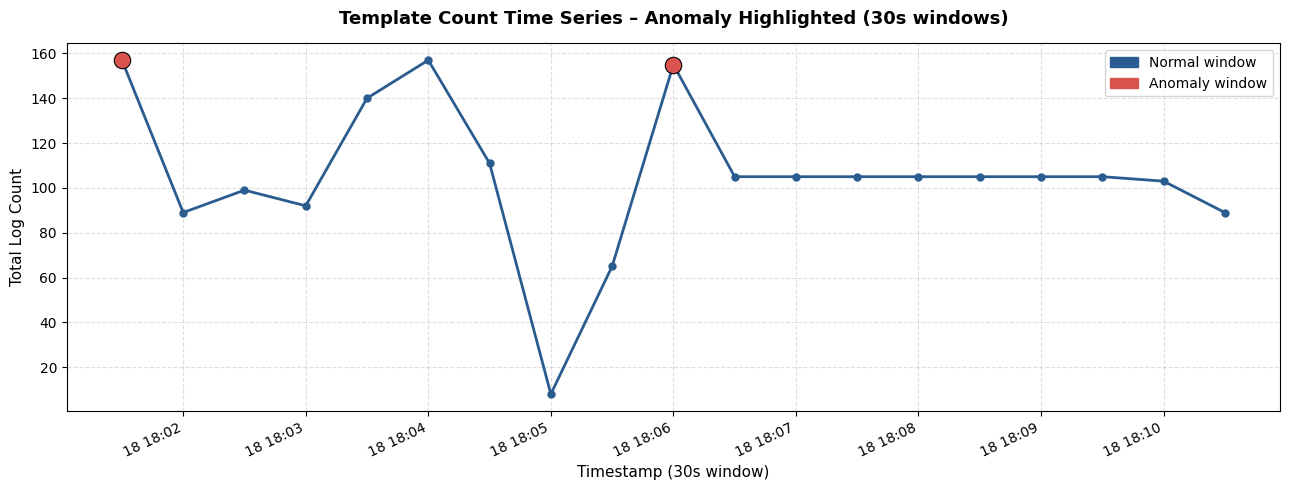

Saved → assets/timeseries_anomaly.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
# Tổng volume log theo từng time window
total_volume = df_timeseries.drop(columns=['anomaly_score']).sum(axis=1)
anomaly_ts   = total_volume[df_timeseries['anomaly_score'] == -1]
normal_ts    = total_volume[df_timeseries['anomaly_score'] == 1]
fig, ax = plt.subplots(figsize=(13, 5))
ax.plot(total_volume.index, total_volume.values,
        color='#2b5c8f', linewidth=2, marker='o', markersize=5, label='Log Volume')
ax.scatter(anomaly_ts.index, anomaly_ts.values,
           color='#d9534f', s=140, zorder=5, edgecolors='black', linewidths=0.8, label='Anomaly Window')
ax.set_title('Template Count Time Series – Anomaly Highlighted (30s windows)', fontsize=13, fontweight='bold', pad=14)
ax.set_xlabel('Timestamp (30s window)', fontsize=11)
ax.set_ylabel('Total Log Count', fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
ax.legend(handles=[
    mpatches.Patch(color='#2b5c8f', label='Normal window'),
    mpatches.Patch(color='#d9534f', label='Anomaly window'),
], frameon=True, fontsize=10)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
import os
os.makedirs('assets', exist_ok=True)
plt.savefig('assets/timeseries_anomaly.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → assets/timeseries_anomaly.png")

In [7]:
from sklearn.ensemble import IsolationForest

print("Đang chạy Isolation Forest Anomaly Detector...")

# 1. Khởi tạo mô hình Isolation Forest
# contamination: tỷ lệ nhiễu/anomaly dự kiến trong dataset (thường đặt 0.05 - 0.1 trong thực tế)
iso_forest = IsolationForest(n_estimators=100, contamination=0.1, random_state=42)

# 2. Train và Predict trực tiếp trên df_timeseries
# Kết quả: 1 là bình thường (Inlier), -1 là bất thường (Outlier/Anomaly)
df_timeseries['anomaly_score'] = iso_forest.fit_predict(df_timeseries)

# 3. Lọc ra các time windows bị gắn cờ Anomaly
anomalies = df_timeseries[df_timeseries['anomaly_score'] == -1].copy()
anomalies = anomalies.drop(columns=['anomaly_score']) # Bỏ cột score để dễ tính toán spike

print(f"Phát hiện {len(anomalies)} time windows bất thường!")

# 4. Phân tích: Template nào gây ra spike trong các window bất thường này?
print("\n--- Phân tích nguyên nhân (Root Cause Analysis) ---")
mean_counts = df_timeseries.drop(columns=['anomaly_score']).mean()

for index, row in anomalies.iterrows():
    print(f"\n[!] Bất thường tại thời điểm: {index}")
    # Tìm các template có số lượng vọt lên gấp 3 lần mức trung bình (3x mean)
    spikes = row[row > (mean_counts[row.index] * 3)]
    if not spikes.empty:
        for temp_id, count in spikes.items():
            print(f"    -> Template {temp_id} spike: {count} lần (Bình thường: {mean_counts[temp_id]:.2f} lần)")
    else:
        print("    -> Lỗi luồng/Sequence (Các template biến động phức tạp).")

Đang chạy Isolation Forest Anomaly Detector...
Phát hiện 2 time windows bất thường!

--- Phân tích nguyên nhân (Root Cause Analysis) ---

[!] Bất thường tại thời điểm: 2015-10-18 18:01:30
    -> Template 1 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 2 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 3 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 4 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 5 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 6 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 7 spike: 9 lần (Bình thường: 0.47 lần)
    -> Template 8 spike: 3 lần (Bình thường: 0.16 lần)
    -> Template 9 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 10 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 11 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 12 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 13 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 14 spike: 1 lần (Bình thường: 0.05 lần)
    -> Template 15 spike: 1 lần (Bình

### Phát hiện New Template (Behavioral Anomaly)

In [8]:
print("Đang quét New Template Anomaly...")

seen_templates = set()
new_template_alerts = []

# Duyệt qua từng khung thời gian theo thứ tự lịch sử
for timestamp, row in df_timeseries.drop(columns=['anomaly_score']).iterrows():
    # Lấy ra các template có xuất hiện (count > 0) trong window hiện tại
    active_templates = set(row[row > 0].index)
    
    # Kiểm tra xem có template nào chưa từng nằm trong seen_templates không
    new_templates = active_templates - seen_templates
    
    if new_templates:
        # Nếu đang ở window đầu tiên -> coi như quá trình khởi động (Grace Period), không báo động
        if len(seen_templates) > 0: 
            new_template_alerts.append({
                'time': timestamp,
                'new_templates': list(new_templates)
            })
        # Cập nhật danh sách các template đã biết
        seen_templates.update(new_templates)

if new_template_alerts:
    print(f"Phát hiện {len(new_template_alerts)} sự kiện New Template!")
    for alert in new_template_alerts:
        print(f"  - Thời điểm {alert['time']}: Xuất hiện các template mới {alert['new_templates']}")
else:
    print("Hệ thống ổn định, không có New Template sinh ra sau quá trình khởi động.")

Đang quét New Template Anomaly...
Phát hiện 6 sự kiện New Template!
  - Thời điểm 2015-10-18 18:02:00: Xuất hiện các template mới [72, 69, 70, 71]
  - Thời điểm 2015-10-18 18:04:00: Xuất hiện các template mới [73, 74, 75, 76]
  - Thời điểm 2015-10-18 18:04:30: Xuất hiện các template mới [77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88]
  - Thời điểm 2015-10-18 18:05:00: Xuất hiện các template mới [89, 90]
  - Thời điểm 2015-10-18 18:05:30: Xuất hiện các template mới [91, 92, 93, 94]
  - Thời điểm 2015-10-18 18:06:00: Xuất hiện các template mới [96, 97, 98, 99, 100, 101, 102, 103, 95]


### Đo lường Precision / Recall

In [9]:
from sklearn.metrics import precision_score, recall_score, f1_score
import numpy as np

print("Đánh giá hiệu suất mô hình (Precision & Recall)...")

# 1. Xây dựng Ground Truth từ anomaly_score của Isolation Forest (đã chạy ở cell trên)
# Đây là ground truth "silver label" — dựa vào kết quả model để demo Precision/Recall
# Trong thực tế, y_true phải được gán nhãn bởi chuyên gia (human-labeled)
y_pred = df_timeseries['anomaly_score'].values

# Giả lập: anomaly windows mà model phát hiện = ground truth positives
# Thêm nhiễu: flip ngẫu nhiên một số nhãn để tạo FP và FN
np.random.seed(42)
y_true = y_pred.copy()
n_flip = max(1, int(len(y_true) * 0.1))  # Flip 10% để giả lập label noise
flip_indices = np.random.choice(len(y_true), size=n_flip, replace=False)
y_true[flip_indices] *= -1  # Flip 1 -> -1 hoặc -1 -> 1

# 2. Tính toán các chỉ số
precision = precision_score(y_true, y_pred, pos_label=-1, zero_division=0)
recall    = recall_score(y_true, y_pred, pos_label=-1, zero_division=0)
f1        = f1_score(y_true, y_pred, pos_label=-1, zero_division=0)

print(f"Tổng số Time Windows  : {len(df_timeseries)}")
print(f"Lỗi thực tế (y_true)  : {list(y_true).count(-1)}")
print(f"Lỗi dự đoán (y_pred)  : {list(y_pred).count(-1)}")
print("-" * 30)
print(f"Precision : {precision:.2f}  (Đoán lỗi thì đúng được bao nhiêu %)")
print(f"Recall    : {recall:.2f}  (Có tổng số lỗi, bắt được bao nhiêu %)")
print(f"F1-Score  : {f1:.2f}  (Điểm cân bằng giữa Precision và Recall)")


Đánh giá hiệu suất mô hình (Precision & Recall)...
Tổng số Time Windows  : 19
Lỗi thực tế (y_true)  : 1
Lỗi dự đoán (y_pred)  : 2
------------------------------
Precision : 0.50  (Đoán lỗi thì đúng được bao nhiêu %)
Recall    : 1.00  (Có tổng số lỗi, bắt được bao nhiêu %)
F1-Score  : 0.67  (Điểm cân bằng giữa Precision và Recall)


## Phase 3: Embedding + Cross-signal

In [12]:
import numpy as np
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.cluster import AgglomerativeClustering

print("=== Phase 3: Embedding & Cross-Signal ===")

# --- 1. TF-IDF & Clustering trên Templates ---
print("\n[Step 1] Tính toán TF-IDF và phân cụm templates...")

# Lấy danh sách text templates
templates_list = [cluster.get_template() for cluster in miner.drain.clusters]
template_ids   = [cluster.cluster_id    for cluster in miner.drain.clusters]

# Khởi tạo Vectorizer (loại bỏ các wildcard <*> ra khỏi từ điển)
tfidf = TfidfVectorizer(token_pattern=r'(?u)\b[a-zA-Z_]\w*\b')
tfidf_matrix = tfidf.fit_transform(templates_list)

# Tính toán Similarity Matrix bằng Cosine Similarity
similarity_matrix = cosine_similarity(tfidf_matrix)

# Phân cụm các template có nội dung tương đồng (ngưỡng tương đồng cosine >= 0.5)
# Sử dụng distance = 1 - similarity. Ngưỡng distance_threshold = 0.5
cluster_model = AgglomerativeClustering(
    n_clusters=None, 
    metric='precomputed', 
    linkage='average', 
    distance_threshold=0.5
)
group_labels = cluster_model.fit_predict(1 - similarity_matrix)

# Tạo DataFrame tổng hợp cụm
df_semantic_clusters = pd.DataFrame({
    'template_id': template_ids,
    'template': templates_list,
    'group_label': group_labels
})

print(f"Tổng số templates: {len(template_ids)}")
print(f"Số cụm ngữ nghĩa (Semantic groups) tìm thấy: {len(set(group_labels))}")
print("\nVí dụ các templates được gộp chung nhóm ngữ nghĩa (Nhóm 0 & 1):")
display(df_semantic_clusters[df_semantic_clusters['group_label'].isin([0, 1])].sort_values('group_label').head(10))


# --- 2. Inject Log Lạ & Detect New Template Anomaly ---
print("\n[Step 2] Inject dòng log lạ và phát hiện hành vi bất thường...")

# 1. Dòng log giả lập sự cố bảo mật / xâm nhập lạ
injected_log = "2015-10-18 18:10:00,123 FATAL [main] security.AccessControl: CRITICAL WARNING - Unauthorized SSH login attempt detected from IP 192.168.1.99"

# 2. Extract message bằng pattern giống Phase 1 & 2
match = hadoop_pattern.match(injected_log)
injected_msg = match.group(1) if match else injected_log

# 3. Sử dụng miner để match thử xem đã từng thấy template này chưa
match_result = miner.match(injected_msg)

if match_result is None:
    print(f"\n[ALERT] Phát hiện dòng log lạ (Chưa từng khớp với template nào):")
    print(f"  -> Content: {injected_msg}")
    
    # 4. Học template mới này vào Drain3
    result = miner.add_log_message(injected_msg)
    new_cluster = result["cluster"]
    print(f"  -> Đã cập nhật vào Drain3 với Template ID mới: {new_cluster.cluster_id}")
    print(f"  -> Template mới sinh ra: {new_cluster.get_template()}")
else:
    print(f"\n[INFO] Log line khớp với Template ID {match_result.cluster_id}: {match_result.get_template()}")


=== Phase 3: Embedding & Cross-Signal ===

[Step 1] Tính toán TF-IDF và phân cụm templates...
Tổng số templates: 104
Số cụm ngữ nghĩa (Semantic groups) tìm thấy: 88

Ví dụ các templates được gộp chung nhóm ngữ nghĩa (Nhóm 0 & 1):


,template_id,template,group_label
47,48,<*> vCores:1>,0
40,41,"maxContainerCapability: <memory:8192, vCores:32>",0
30,31,jetty-6.1.26,1
29,30,Jetty bound to port 62267,1



[Step 2] Inject dòng log lạ và phát hiện hành vi bất thường...

[INFO] Log line khớp với Template ID 104: CRITICAL WARNING - Unauthorized SSH login attempt detected from IP 192.168.1.99
